## Imports (mandatory for running codes)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

---
## Data Cleaning

In [ ]:
# ================= TenneT dataset =================
df = pd.read_csv('tennet/time_series_15min_singleindex_filtered.csv')
df['DE_tennet_wind_offshore_generation_actual'] = (
    df['DE_tennet_wind_offshore_generation_actual'].fillna(method='ffill')
)
missing_count = df['DE_tennet_wind_offshore_generation_actual'].isnull().sum()
print(f"Remaining NaN count: {missing_count}")
df.to_csv('time_series_15min_cleaned.csv', index=False)#move to data/tennet
print("Saved: time_series_15min_cleaned.csv")

## Seasonal Test

In [2]:
pip install pymannkendall

In [5]:
import pymannkendall as mk

df = pd.read_csv('tennet/time_series_15min_cleaned.csv')
a = np.array(df['DE_tennet_wind_offshore_generation_actual'].values)

result = mk.original_test(a)
print(result)

---
## Visualization (Fig 2)

In [ ]:
plt.figure(figsize=(16, 6))
plt.plot(a, color='red', linewidth=1)
plt.title('Offshore Wind Power DataSet in TenneT', fontsize=14, fontweight='bold')
plt.ylabel('Offshore wind power (MW)', fontsize=12)
plt.xlabel('2020.1.1 00:00-2020.9.30 23:45 (UTC time, 15min)', fontsize=12)
plt.ylim(0, 6435.69)
plt.xlim(0, 26304)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("fig2tennet.png", dpi=400)
plt.show()

# **Tennet Dataset**

### TVFEMD + R2CMSE

In [2]:
pip install pytvfemd pyinstrument line_profiler

Looking in indexes: https://mirrors.aliyun.com/pypi/simple/
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pytvfemd]
Note: you may need to restart the kernel to use updated packages.


In [3]:
df = pd.read_csv('tennet/time_series_15min_cleaned.csv')
a = np.array(df['DE_tennet_wind_offshore_generation_actual'].values)

In [ ]:
from line_profiler import LineProfiler
from pytvfemd import tvfemd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform


# ================4.1 TVFEMD Decomposition + Table 9 (thresh_bwr sensitivity)==================
thresh_bwr_values = [0.10, 0.12, 0.14, 0.16, 0.18, 0.20, 0.25, 0.30]
sensitivity_results = {}
imf_default = None
col_names = None

print("=== TVFEMD thresh_bwr Sensitivity Analysis (Table 9) ===")
for tbwr in thresh_bwr_values:
    print(f"\n  thresh_bwr = {tbwr:.2f}")
    try:
        #TVFEMD results
        if tbwr == 0.10:
            lp = LineProfiler()
            lp.add_function(tvfemd)
            lp_wrapper = lp(tvfemd)
            #Table 8. TVFEMD execution time, only thresh_bwr == 0.1
            imf_s = lp_wrapper(a, bsp_order=28)  
            lp.print_stats()
        else:
            imf_s = tvfemd(a, bsp_order=28, thresh_bwr=tbwr)
            fname = f"tvfemd_TenneT_thresh{str(tbwr).replace('.','p')}.csv"
            s_cols = [f"IMF{i+1}" for i in range(imf_s.shape[1]-1)] + ["residual"]
            pd.DataFrame(imf_s, columns=s_cols).to_csv(fname, index=False)
            
        sensitivity_results[tbwr] = imf_s
        print(f"shape: {imf_s.shape}  (n_IMFs={imf_s.shape[1]-1})")

        if tbwr == 0.10:
            imf_default = imf_s
            col_names = [f"IMF{i+1}" for i in range(imf_s.shape[1] - 1)] + ["residual"]
            pd.DataFrame(imf_default, columns=col_names).to_csv(
                "tvfemdresults_TenneT.csv", index=False
            )
            print("Default result saved: tvfemdresults_TenneT.csv")#move to data/tennet

    except Exception as e:
        print(f"    FAILED: {e}")
        sensitivity_results[tbwr] = None

# ============================Table 9 summary=============================================
print("\n=== Summary: n_IMFs by thresh_bwr (Table 9) ===")
for tbwr, res in sensitivity_results.items():
    n = res.shape[1] - 1 if res is not None else "ERROR"
    print(f"  thresh_bwr={tbwr:.2f}, n_IMFs={n}")


# =======================Figure 3(a):plot TVFEMD results=================================
de_default = pd.DataFrame(imf_default, columns=col_names)
axes = de_default.plot(subplots=True, legend=False, figsize=(22, 12), fontsize=12)
for i in range(len(col_names) - 1):
    axes[i].set_ylabel(f'IMF{i+1}', labelpad=25.5, rotation='horizontal', fontsize=12)
axes[-1].set_ylabel('Residual', labelpad=25.5, rotation='horizontal', fontsize=12)
plt.xlim(0, 26304)
plt.tight_layout()
plt.subplots_adjust(hspace=0.8)
plt.savefig('tvfemd_TENNET.png', dpi=400)
plt.show()
print("Figure 3(a) saved.")

# =======================4.2 R2CMSE:load TVFEMD results===================================
series = imf_default  # shape: (n_samples, n_IMFs)

# =======================R2CMSE core functions ===========================================
def coarse_graining(series, tau):
    L = len(series)
    N = L // tau
    data = np.zeros((tau, N))
    for k in range(tau):
        for i in range(N):
            start = i * tau + k
            end = (i + 1) * tau + k - 1
            segment = series[start:] if end >= L else series[start:end+1]
            data[k, i] = np.mean(segment)
    return data

def sample_entropy_optimized(series, r, m):
    N = len(series)
    if N < m + 1:
        return np.nan, np.nan
    def create_patterns(x, dim):
        return np.lib.stride_tricks.sliding_window_view(x, window_shape=dim)
    def count_matches(patterns, r_val):
        n = len(patterns)
        if n < 2:
            return 0
        dists = squareform(pdist(patterns, metric='chebyshev'))
        np.fill_diagonal(dists, np.inf)
        return np.sum(dists <= r_val)
    patterns_m  = create_patterns(series, m)
    patterns_m1 = create_patterns(series, m + 1)
    B = count_matches(patterns_m,  r)
    A = count_matches(patterns_m1, r)
    N_m, N_m1 = len(patterns_m), len(patterns_m1)
    if B == 0 or A == 0:
        return np.nan, np.nan
    return B / (N_m * (N_m - 1)), A / (N_m1 * (N_m1 - 1))

def r2cmse_value_optimized(series, r, m, tau):
    r_rel = r * np.std(series)
    data = coarse_graining(series, tau)
    tmp1, tmp2 = [], []
    for i in range(tau):
        c2, c3 = sample_entropy_optimized(data[i, :], r_rel, m)
        tmp1.append(c2)
        tmp2.append(c3)
    mean1, mean2 = np.nanmean(tmp1), np.nanmean(tmp2)
    if mean1 == 0 or mean2 == 0:
        return np.nan
    return -np.log(mean2 / mean1)

# ==============R2CMSE Sensitivity Analysis: varying tau (Table 10)=======================
tau_values  = [2, 3, 4, 5, 6]
r_default   = 0.15
m_default   = 2
sensitivity_tau_results = {}
default_r2cmse_results  = None  # tau=2 saved in Figure 3(b)

print("\n=== R2CMSE Execution Time and Sensitivity Analysis: varying tau (Table 9 & 10) ===")
print(f"(r={r_default}, m={m_default}, n_components={series.shape[1]})")
print("-" * 60)

for tau_val in tau_values:
    if tau_val == 2:
        lp = LineProfiler()
        lp.add_function(coarse_graining)
        lp.add_function(sample_entropy_optimized)
        lp.add_function(r2cmse_value_optimized)#Table 8. R2CMSE execution time, only tau == 2

        @lp
        def run_default_r2cmse():
            results = []
            for i in range(series.shape[1]):
                val = r2cmse_value_optimized(series[:, i], r=r_default, m=m_default, tau=tau_val)
                results.append(val)
            return results

        results_tau = run_default_r2cmse()
        lp.print_stats()
        default_r2cmse_results = results_tau
        print(f"tau={tau_val} [default]: {[round(v, 4) if v is not None and not np.isnan(v) else v for v in results_tau]}")
    else: #tau=3,4,5,6
        results_tau = []
        for i in range(series.shape[1]):
            val = r2cmse_value_optimized(series[:, i], r=r_default, m=m_default, tau=tau_val)
            results_tau.append(val)
        print(f"tau={tau_val}:          {[round(v, 4) if v is not None and not np.isnan(v) else v for v in results_tau]}")

    sensitivity_tau_results[tau_val] = results_tau

# =======================Sensitivity results for R2CMSE Table 10 saved=======================
comp_labels = list(de_default.columns)
sens_df = pd.DataFrame(sensitivity_tau_results, index=comp_labels)
sens_df.index.name = "Component"
sens_df.columns = [f"tau={tau}" for tau in tau_values]
sens_df.to_csv("r2cmse_tau_sensitivity.csv")
print("\nSaved: r2cmse_tau_sensitivity.csv")
print(sens_df.to_string())

#Figure 3(b) plot
xf = list(de_default.columns)
yf = default_r2cmse_results

plt.figure(figsize=(8, 6))
plt.scatter(xf, yf)
for i, txt in enumerate(yf):
    if txt is not None and not np.isnan(txt):
        plt.text(xf[i], txt, f'{txt:.3f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.title('R2CMSE values for IMFs')
plt.xlabel('IMF components')
plt.ylabel('R2CMSE Values')
plt.tight_layout()
plt.savefig('R2CMSE_TenneT.png', dpi=400)
plt.show()
print("Figure 3(b) saved: R2CMSE_TenneT.png")

=== TVFEMD thresh_bwr Sensitivity Analysis (Table 9) ===

  thresh_bwr = 0.10


Based on these R2CMSE values, the following reconstructed IMF files and Figure 3 (c) were obtained.

section4/trmg(trqg)/imfreconstruction_TenneT.csv

section5.4.3/trmg1l/imfreconstruction_TenneT.csv

section5.5/trq1g/imfreconstruction_TenneT.csv

For differences in scipy.sparse.linalg.spsolve()

In [ ]:
imf_default = pd.read_csv('tennet/tvfemdresults_TenneT.csv').values

# =======================Figure 3(a):plot TVFEMD results===================================

de_default = pd.DataFrame(imf_default, columns=col_names)
axes = de_default.plot(subplots=True, legend=False, figsize=(22, 12), fontsize=12)
for i in range(len(col_names) - 1):
    axes[i].set_ylabel(f'IMF{i+1}', labelpad=25.5, rotation='horizontal', fontsize=12)
axes[-1].set_ylabel('Residual', labelpad=25.5, rotation='horizontal', fontsize=12)
plt.xlim(0, 26304)
plt.tight_layout()
plt.subplots_adjust(hspace=0.8)
plt.savefig('tvfemd_TENNET.png', dpi=400)
plt.show()
print("Figure 3(a) saved.")

# =======================4.2 R2CMSE:load TVFEMD results===================================
series = imf_default  # shape: (n_samples, n_IMFs)

# =======================R2CMSE core functions=============================================
def coarse_graining(series, tau):
    L = len(series)
    N = L // tau
    data = np.zeros((tau, N))
    for k in range(tau):
        for i in range(N):
            start = i * tau + k
            end = (i + 1) * tau + k - 1
            segment = series[start:] if end >= L else series[start:end+1]
            data[k, i] = np.mean(segment)
    return data

def sample_entropy_optimized(series, r, m):
    N = len(series)
    if N < m + 1:
        return np.nan, np.nan
    def create_patterns(x, dim):
        return np.lib.stride_tricks.sliding_window_view(x, window_shape=dim)
    def count_matches(patterns, r_val):
        n = len(patterns)
        if n < 2:
            return 0
        dists = squareform(pdist(patterns, metric='chebyshev'))
        np.fill_diagonal(dists, np.inf)
        return np.sum(dists <= r_val)
    patterns_m  = create_patterns(series, m)
    patterns_m1 = create_patterns(series, m + 1)
    B = count_matches(patterns_m,  r)
    A = count_matches(patterns_m1, r)
    N_m, N_m1 = len(patterns_m), len(patterns_m1)
    if B == 0 or A == 0:
        return np.nan, np.nan
    return B / (N_m * (N_m - 1)), A / (N_m1 * (N_m1 - 1))

def r2cmse_value_optimized(series, r, m, tau):
    r_rel = r * np.std(series)
    data = coarse_graining(series, tau)
    tmp1, tmp2 = [], []
    for i in range(tau):
        c2, c3 = sample_entropy_optimized(data[i, :], r_rel, m)
        tmp1.append(c2)
        tmp2.append(c3)
    mean1, mean2 = np.nanmean(tmp1), np.nanmean(tmp2)
    if mean1 == 0 or mean2 == 0:
        return np.nan
    return -np.log(mean2 / mean1)

#================ R2CMSE Sensitivity Analysis: varying tau (Table 10)===================
tau_values  = [2, 3, 4, 5, 6]
r_default   = 0.15
m_default   = 2
sensitivity_tau_results = {}
default_r2cmse_results  = None  # tau=2 saved in Figure 3(b)

print("\n=== R2CMSE Execution Time and Sensitivity Analysis: varying tau (Table 9 & 10) ===")
print(f"(r={r_default}, m={m_default}, n_components={series.shape[1]})")
print("-" * 60)

for tau_val in tau_values:
    if tau_val == 2:
        lp = LineProfiler()
        lp.add_function(coarse_graining)
        lp.add_function(sample_entropy_optimized)
        lp.add_function(r2cmse_value_optimized)#Table 8. R2CMSE execution time, only tau == 2

        @lp
        def run_default_r2cmse():
            results = []
            for i in range(series.shape[1]):
                val = r2cmse_value_optimized(series[:, i], r=r_default, m=m_default, tau=tau_val)
                results.append(val)
            return results

        results_tau = run_default_r2cmse()
        lp.print_stats()
        default_r2cmse_results = results_tau
        print(f"tau={tau_val} [default]: {[round(v, 4) if v is not None and not np.isnan(v) else v for v in results_tau]}")
    else: #tau=3,4,5,6
        results_tau = []
        for i in range(series.shape[1]):
            val = r2cmse_value_optimized(series[:, i], r=r_default, m=m_default, tau=tau_val)
            results_tau.append(val)
        print(f"tau={tau_val}:          {[round(v, 4) if v is not None and not np.isnan(v) else v for v in results_tau]}")

    sensitivity_tau_results[tau_val] = results_tau

# ======================Sensitivity results for R2CMSE Table 10 saved===============================
comp_labels = list(de_default.columns)
sens_df = pd.DataFrame(sensitivity_tau_results, index=comp_labels)
sens_df.index.name = "Component"
sens_df.columns = [f"tau={tau}" for tau in tau_values]
sens_df.to_csv("r2cmse_tau_sensitivity.csv")
print("\nSaved: r2cmse_tau_sensitivity.csv")
print(sens_df.to_string())

#Figure 3(b) plot
xf = list(de_default.columns)
yf = default_r2cmse_results

plt.figure(figsize=(8, 6))
plt.scatter(xf, yf)
for i, txt in enumerate(yf):
    if txt is not None and not np.isnan(txt):
        plt.text(xf[i], txt, f'{txt:.3f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.title('R2CMSE values for IMFs')
plt.xlabel('IMF components')
plt.ylabel('R2CMSE Values')
plt.tight_layout()
plt.savefig('R2CMSE_TenneT.png', dpi=400)
plt.show()
print("Figure 3(b) saved: R2CMSE_TenneT.png")

TVFEMD+SE

In [4]:
pip install EntropyHub

Looking in indexes: https://mirrors.aliyun.com/pypi/simple/
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [EntropyHub]7 [EntropyHub]s]
Note: you may need to restart the kernel to use updated packages.


In [2]:
#Use TVFEMD results directly
de_arr = pd.read_csv('tennet/tvfemdresults_TenneT.csv').values

In [6]:
# ===============Sample Entropy =========================
from EntropyHub import SampEn
from line_profiler import LineProfiler
def calculate_sampen(data, m=2, r=0.15):
    return SampEn(data, m=m, r=r)[0][-1]

lp_se = LineProfiler()
lp_se.add_function(calculate_sampen)

def run_sampen_analysis():
    results_sampen = []
    for i in range(de_arr.shape[1]):
        results_sampen.append(calculate_sampen(de_arr[:, i], m=2, r=0.15))
    print(f"SampEn: {results_sampen}")
    return results_sampen

lp_se_wrapper = lp_se(run_sampen_analysis)
sampen_results = lp_se_wrapper()
lp_se.print_stats()

SampEn: [np.float64(2.767508271007362), np.float64(3.3956790389237086), np.float64(3.156747096259588), np.float64(3.1580636854714434), np.float64(2.3425747412102043), np.float64(2.13000318549765), np.float64(1.8148551840227043), np.float64(1.3938415667552735), np.float64(1.127753423575609), np.float64(1.0353942166750423), np.float64(0.7350095259208572), np.float64(0.735429901719323), np.float64(0.7598385550586176), np.float64(0.726984995341504), np.float64(0.7537718023763802)]
Timer unit: 1e-09 s

Total time: 372.606 s
File: /tmp/ipykernel_1573/2300070085.py
Function: calculate_sampen at line 4

Line #      Hits         Time  Per Hit   % Time  Line Contents
     4                                           def calculate_sampen(data, m=2, r=0.15):
     5        15     3.73e+11 2.48e+10    100.0      return SampEn(data, m=m, r=r)[0][-1]

Total time: 372.608 s
File: /tmp/ipykernel_1573/2300070085.py
Function: run_sampen_analysis at line 10

Line #      Hits         Time  Per Hit   % Time  

Based on results, the following reconstructed IMF file and Appendix D.4 were obtained:

section4/tsmg/sereconstruction.csv

TVFEMD+FE (ablation analysis)

In [8]:
#Use TVFEMD results directly, only TenneT dataset
de_arr = pd.read_csv('tennet/tvfemdresults_TenneT.csv').values

In [10]:
# ============== Fuzzy Entropy =============================
from EntropyHub import FuzzEn
def FuzzyEn2(s, r=0.2, m=2, n=2):
    th = r * np.std(s)
    return FuzzEn(s, 2, r=(th, n))[0][-1]

def run_fuzzyen_analysis():
    results_fuzzyen = []
    for i in range(de_arr.shape[1]):
        results_fuzzyen.append(FuzzyEn2(de_arr[:, i]))
    print(f"FuzzyEn: {results_fuzzyen}")
    return results_fuzzyen

fuzzyen_results = run_fuzzyen_analysis()

FuzzyEn: [np.float64(2.088535523761934), np.float64(2.0834180354976044), np.float64(1.7594156603420017), np.float64(1.388792063254173), np.float64(1.0654176137051765), np.float64(0.869813792003971), np.float64(0.7632972663865121), np.float64(0.6891702222245313), np.float64(0.6790931633127872), np.float64(0.6522141275185083), np.float64(0.6067992767475721), np.float64(0.5486594699408314), np.float64(0.5044616682285104), np.float64(0.43125935776847624), np.float64(0.35271074366840205)]


Based on results, the following reconstructed IMF files are obtained:

section5.5/tfmg/fuzzy.csv

**fuzzy.csv in section5.5/tfmg file**
| IMF | R2CMSE values | Reconstruction for TRMG |
|:---:|:---:|:---:|
| IMF1 | 2.088535523761934 | sub1 |
| IMF2 | 2.0834180354976044 | sub1 |
| IMF3 | 1.7594156603420017 | sub1 |
| IMF4 | 1.388792063254173 | sub2 |
| IMF5 | 1.0654176137051765 | sub3 |
| IMF6 | 0.869813792003971 | sub3 |
| IMF7 | 0.7632972663865121 | sub3 |
| IMF8 | 0.6891702222245313 | sub3 |
| IMF9 | 0.6790931633127872 | sub3 |
| IMF10 | 0.6522141275185083 | sub3 |
| IMF11 | 0.6067992767475721 | sub4 |
| IMF12 | 0.5486594699408314 | sub4 |
| IMF13 | 0.5044616682285104 | sub4 |
| Res | 0.43125935776847624 | sub5 |
| Res | 0.3527107448964 | sub5 |

WT+R2CMSE

In [ ]:
df=pd.read_csv('tennet/time_series_15min_cleaned.csv')
a = np.array(df['DE_tennet_wind_offshore_generation_actual'].values)

In [ ]:
#================WT decomposition=============================
import pywt
from line_profiler import LineProfiler
from scipy.spatial.distance import pdist, squareform

lp = LineProfiler()
lp.add_function(pywt.wavedec)

signal_1d = a
def wavelet_decomp_wrapper(signal):
    return pywt.wavedec(signal, wavelet='db4', level=None)

lp_wrapper = lp(wavelet_decomp_wrapper)
coeffs = lp_wrapper(a)
lp.print_stats() #Table 8 WT decomposition time

coeffs = pywt.wavedec(signal_1d, wavelet='db4', level=None)
N = len(signal_1d)

def reconstruct_imfs(coeffs, wavelet='db4', original_length=None):
    if original_length is None:
        original_length = len(coeffs[-1]) * 2
    imfs = []
    for i in range(1, len(coeffs)):
        coeffs_i = [np.zeros_like(c) for c in coeffs]
        coeffs_i[i] = coeffs[i]
        imfs.append(pywt.waverec(coeffs_i, wavelet)[:original_length])
    coeffs_approx = [coeffs[0]] + [np.zeros_like(c) for c in coeffs[1:]]
    trend = pywt.waverec(coeffs_approx, wavelet)[:original_length]
    return imfs, trend

imfs_wt, trend_wt = reconstruct_imfs(coeffs, wavelet='db4', original_length=N)

data_dict = {'Trend': trend_wt}
data_dict.update({f'IMF{i+1}': imf for i, imf in enumerate(imfs_wt)})
pd.DataFrame(data_dict).to_csv('wt_results.csv', index=False)# move to data/tennet

# =======================R2CMSE core functions==========================

imf_keys = [k for k in data_dict.keys() if k.startswith('IMF')]
all_keys =   imf_keys + ['Trend']
series = np.column_stack([data_dict[k] for k in all_keys])

def coarse_graining(series, tau):
    L = len(series)
    N = L // tau
    data = np.zeros((tau, N))
    for k in range(tau):
        for i in range(N):
            start = i * tau + k
            end = (i + 1) * tau + k - 1
            segment = series[start:] if end >= L else series[start:end+1]
            data[k, i] = np.mean(segment)
    return data

def sample_entropy_optimized(series, r, m):
    N = len(series)
    if N < m + 1:
        return np.nan, np.nan
    def create_patterns(x, dim):
        return np.lib.stride_tricks.sliding_window_view(x, window_shape=dim)
    def count_matches(patterns, r_val):
        n = len(patterns)
        if n < 2:
            return 0
        dists = squareform(pdist(patterns, metric='chebyshev'))
        np.fill_diagonal(dists, np.inf)
        return np.sum(dists <= r_val)
    patterns_m  = create_patterns(series, m)
    patterns_m1 = create_patterns(series, m + 1)
    B = count_matches(patterns_m,  r)
    A = count_matches(patterns_m1, r)
    N_m, N_m1 = len(patterns_m), len(patterns_m1)
    if B == 0 or A == 0:
        return np.nan, np.nan
    return B / (N_m * (N_m - 1)), A / (N_m1 * (N_m1 - 1))

def r2cmse_value_optimized(series, r, m, tau):
    r_rel = r * np.std(series)
    data = coarse_graining(series, tau)
    tmp1, tmp2 = [], []
    for i in range(tau):
        c2, c3 = sample_entropy_optimized(data[i, :], r_rel, m)
        tmp1.append(c2)
        tmp2.append(c3)
    mean1, mean2 = np.nanmean(tmp1), np.nanmean(tmp2)
    if mean1 == 0 or mean2 == 0:
        return np.nan
    return -np.log(mean2 / mean1)

# =======================R2CMSE results====================
tau_values  = 2
r_default   = 0.15
m_default   = 2

print(f"(r={r_default}, m={m_default}, n_components={series.shape[1]})")

def run_r2cmse(tau, r, m):
    results = []
    for i in range(series.shape[1]):
        val = r2cmse_value_optimized(series[:, i], r=r, m=m, tau=tau)
        results.append(val)
    return results

lp = LineProfiler()
lp.add_function(coarse_graining)
lp.add_function(sample_entropy_optimized)
lp.add_function(r2cmse_value_optimized)
lp_wrapper = lp(run_r2cmse)

results_tau = lp_wrapper(tau=tau_values, r=r_default, m=m_default)

lp.print_stats()#Table 8. R2CMSE execution time for WRGG
print(results_tau)

Based on results_tau, the following reconstructed IMF files and Appendix Table D.1 were obtained:

section4/wrgg/wt_decomposition_results.csv

VMD+R2CMSE

In [6]:
pip install vmdpy pyswarm antropy line_profiler

Looking in indexes: https://mirrors.aliyun.com/pypi/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 4.6 MB/s  0:00:00 eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 5.6 MB/s  0:00:06m0:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 5.8 MB/s  0:00:01 eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 6.1 MB/s  0:00:00 eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 5.7 MB/s  0:00:09m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [antropy]8/10 [numba]-learn]
Note: you may need to restart the kernel to use updated packages.


In [7]:
df=pd.read_csv('tennet/time_series_15min_cleaned.csv')
a = np.array(df['DE_tennet_wind_offshore_generation_actual'].values)

In [8]:
from line_profiler import LineProfiler
from vmdpy import VMD
from pyswarm import pso
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import antropy as ant
from scipy.spatial.distance import pdist, squareform
# ==================VMD decomposition===========================
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)

set_seed(42)

class VMD_PSO_Optimizer:
    def __init__(self, signal, tau=0, DC=0, init=1, tol=1e-7, seed=42):
        self.signal = signal
        self.tau = tau
        self.DC = DC
        self.init = init
        self.tol = tol
        self.eval_count = 0
        self.seed = seed
        set_seed(self.seed)
        self.profiler = LineProfiler()

    def fitness_function(self, params):
        K = max(2, min(int(np.round(params[0])), 17))
        alpha = np.round(params[1] / 500) * 500
        try:
            u, u_hat, omega = VMD(self.signal, alpha=alpha, tau=self.tau,
                                  K=K, DC=self.DC, init=self.init, tol=self.tol)
            reconstructed = np.sum(u, axis=0)
            min_len = min(len(self.signal), len(reconstructed))
            fitness = mean_squared_error(self.signal[:min_len], reconstructed[:min_len])
            self.eval_count += 1
            if self.eval_count % 10 == 0:
                print(f"Trial {self.eval_count}: K={K}, alpha={alpha:.0f}, fitness={fitness:.6f}")
            return fitness
        except Exception as e:
            print(f"Decomposition failed: K={K}, alpha={alpha}, Error: {e}")
            return 1e10

    def optimize(self, K_range=(2, 17), alpha_range=(500, 5000), swarmsize=20, maxiter=50):
        set_seed(self.seed)
        print("="*60)
        print(f"Starting PSO | K range: {K_range} | Alpha range: {alpha_range} | seed: {self.seed}")
        print("="*60)
        best_params, best_fitness = pso(
            self.fitness_function, [K_range[0], alpha_range[0]], [K_range[1], alpha_range[1]],
            swarmsize=swarmsize, maxiter=maxiter,
            omega=0.5, phip=1.5, phig=1.5, debug=True
        )
        best_K = int(np.round(best_params[0]))
        best_alpha = np.round(best_params[1] / 500) * 500
        print(f"Best K: {best_K} | Best Alpha: {best_alpha:.0f} | Best fitness: {best_fitness:.6f}")
        return [best_K, best_alpha], best_fitness

    def decompose(self, best_params):
        K, alpha = int(best_params[0]), best_params[1]
        print(f"\nVMD decomposition: K={K}, alpha={alpha:.0f}")
        u, u_hat, omega = VMD(self.signal, alpha=alpha, tau=self.tau,
                              K=K, DC=self.DC, init=self.init, tol=self.tol)
        return u, u_hat, omega

    def profile_optimization(self, K_range=(2, 8), alpha_range=(500, 3000), swarmsize=15, maxiter=30):
        self.profiler.add_function(self.fitness_function)
        self.profiler.add_function(self.optimize)
        self.profiler.add_function(self.decompose)
        self.profiler.enable()
        best_params, best_fitness = self.optimize(K_range, alpha_range, swarmsize, maxiter)
        self.profiler.disable()
        self.profiler.print_stats()
        return best_params, best_fitness # VMD execution time

    def profile_decomposition(self, best_params):
        dec_profiler = LineProfiler()
        dec_profiler.add_function(self.decompose)
        dec_profiler.enable()
        u, u_hat, omega = self.decompose(best_params)
        dec_profiler.disable()
        dec_profiler.print_stats()
        return u, u_hat, omega


optimizer = VMD_PSO_Optimizer(a)
best_params, best_fitness = optimizer.profile_optimization(
    K_range=(2, 17), alpha_range=(2000, 3000), swarmsize=10, maxiter=20
)
u, u_hat, omega = optimizer.profile_decomposition(best_params)

vimf = u.T
pd.DataFrame(vimf).to_csv('vmd_decomposition_results.csv', index=False)  # move to data/tennet

series=vimf

# ========================= R2CMSE core functions ==============================
def coarse_graining(series, tau):
    L = len(series)
    N = L // tau
    data = np.zeros((tau, N))
    for k in range(tau):
        for i in range(N):
            start = i * tau + k
            end = (i + 1) * tau + k - 1
            segment = series[start:] if end >= L else series[start:end+1]
            data[k, i] = np.mean(segment)
    return data

def sample_entropy_optimized(series, r, m):
    N = len(series)
    if N < m + 1:
        return np.nan, np.nan
    def create_patterns(x, dim):
        return np.lib.stride_tricks.sliding_window_view(x, window_shape=dim)
    def count_matches(patterns, r_val):
        n = len(patterns)
        if n < 2:
            return 0
        dists = squareform(pdist(patterns, metric='chebyshev'))
        np.fill_diagonal(dists, np.inf)
        return np.sum(dists <= r_val)
    patterns_m  = create_patterns(series, m)
    patterns_m1 = create_patterns(series, m + 1)
    B = count_matches(patterns_m,  r)
    A = count_matches(patterns_m1, r)
    N_m, N_m1 = len(patterns_m), len(patterns_m1)
    if B == 0 or A == 0:
        return np.nan, np.nan
    return B / (N_m * (N_m - 1)), A / (N_m1 * (N_m1 - 1))

def r2cmse_value_optimized(series, r, m, tau):
    r_rel = r * np.std(series)
    data = coarse_graining(series, tau)
    tmp1, tmp2 = [], []
    for i in range(tau):
        c2, c3 = sample_entropy_optimized(data[i, :], r_rel, m)
        tmp1.append(c2)
        tmp2.append(c3)
    mean1, mean2 = np.nanmean(tmp1), np.nanmean(tmp2)
    if mean1 == 0 or mean2 == 0:
        return np.nan
    return -np.log(mean2 / mean1)

#========================= R2CMSE results=======================================
tau_values  = 2
r_default   = 0.15
m_default   = 2
sensitivity_tau_results = {}
default_r2cmse_results  = None

print(f"(r={r_default}, m={m_default}, n_components={series.shape[1]})")
print("-" * 60)

def run_r2cmse(tau, r, m):
    results = []
    for i in range(series.shape[1]):
        val = r2cmse_value_optimized(series[:, i], r=r, m=m, tau=tau)
        results.append(val)
    return results


lp = LineProfiler()
lp.add_function(coarse_graining)
lp.add_function(sample_entropy_optimized)
lp.add_function(r2cmse_value_optimized)
lp_wrapper = lp(run_r2cmse)

results_tau = lp_wrapper(tau=tau_values, r=r_default, m=m_default)
lp.print_stats()#Table 8. R2CMSE execution time for VRLG

print(results_tau)

Starting PSO | K range: (2, 17) | Alpha range: (2000, 3000) | seed: 42
No constraints given.
Trial 10: K=10, alpha=3000, fitness=1899.370672
Trial 20: K=16, alpha=3000, fitness=517.437871
New best for swarm at iteration 1: [  17. 2000.] 224.65194134017062
Best after iteration 1: [  17. 2000.] 224.65194134017062
Trial 30: K=17, alpha=2000, fitness=224.651941
Best after iteration 2: [  17. 2000.] 224.65194134017062
Trial 40: K=17, alpha=2000, fitness=224.651941
Best after iteration 3: [  17. 2000.] 224.65194134017062
Trial 50: K=17, alpha=2000, fitness=224.651941
Best after iteration 4: [  17. 2000.] 224.65194134017062
Trial 60: K=17, alpha=2000, fitness=224.651941
Best after iteration 5: [  17. 2000.] 224.65194134017062
Trial 70: K=17, alpha=2000, fitness=224.651941
Best after iteration 6: [  17. 2000.] 224.65194134017062
Trial 80: K=17, alpha=2000, fitness=224.651941
Best after iteration 7: [  17. 2000.] 224.65194134017062
Trial 90: K=17, alpha=2000, fitness=224.651941
Best after itera

Based on results_tau, the following reconstructed IMF files and Appendix Table D.2 were obtained:

section4/vrlg/vmd_reconstruction.csv

EMD+R2CMSE

In [ ]:
pip install EMD-signal

In [ ]:
df=pd.read_csv('tennet/time_series_15min_cleaned.csv')
a = np.array(df['DE_tennet_wind_offshore_generation_actual'].values)

In [ ]:
from PyEMD import EMD
from line_profiler import LineProfiler
from scipy.spatial.distance import pdist, squareform

#===========================EMD decomposition================================
emd = EMD()

lp = LineProfiler()
lp.add_function(emd.__call__)
lp_wrapper = lp(emd)

IMFs = lp_wrapper(a)
lp.print_stats() #Table 8 EMD decomposition time

IMFs = IMFs.T

emd_cols = [f"IMF{i+1}" for i in range(IMFs.shape[1] - 1)] + ["residual"]
pd.DataFrame(IMFs, columns=emd_cols).to_csv('emdresults.csv', index=False)  #move to data/tennet

series = IMFs

# ==========================R2CMSE core functions===========================
def coarse_graining(series, tau):
    L = len(series)
    N = L // tau
    data = np.zeros((tau, N))
    for k in range(tau):
        for i in range(N):
            start = i * tau + k
            end = (i + 1) * tau + k - 1
            segment = series[start:] if end >= L else series[start:end+1]
            data[k, i] = np.mean(segment)
    return data

def sample_entropy_optimized(series, r, m):
    N = len(series)
    if N < m + 1:
        return np.nan, np.nan
    def create_patterns(x, dim):
        return np.lib.stride_tricks.sliding_window_view(x, window_shape=dim)
    def count_matches(patterns, r_val):
        n = len(patterns)
        if n < 2:
            return 0
        dists = squareform(pdist(patterns, metric='chebyshev'))
        np.fill_diagonal(dists, np.inf)
        return np.sum(dists <= r_val)
    patterns_m  = create_patterns(series, m)
    patterns_m1 = create_patterns(series, m + 1)
    B = count_matches(patterns_m,  r)
    A = count_matches(patterns_m1, r)
    N_m, N_m1 = len(patterns_m), len(patterns_m1)
    if B == 0 or A == 0:
        return np.nan, np.nan
    return B / (N_m * (N_m - 1)), A / (N_m1 * (N_m1 - 1))

def r2cmse_value_optimized(series, r, m, tau):
    r_rel = r * np.std(series)
    data = coarse_graining(series, tau)
    tmp1, tmp2 = [], []
    for i in range(tau):
        c2, c3 = sample_entropy_optimized(data[i, :], r_rel, m)
        tmp1.append(c2)
        tmp2.append(c3)
    mean1, mean2 = np.nanmean(tmp1), np.nanmean(tmp2)
    if mean1 == 0 or mean2 == 0:
        return np.nan
    return -np.log(mean2 / mean1)

# ================== R2CMSE results======================
tau_values  = 2
r_default   = 0.15
m_default   = 2

print(f"(r={r_default}, m={m_default}, n_components={series.shape[1]})")

def run_r2cmse(tau, r, m):
    results = []
    for i in range(series.shape[1]):
        val = r2cmse_value_optimized(series[:, i], r=r, m=m, tau=tau)
        results.append(val)
    return results

lp = LineProfiler()
lp.add_function(coarse_graining)
lp.add_function(sample_entropy_optimized)
lp.add_function(r2cmse_value_optimized)
lp_wrapper = lp(run_r2cmse)

results_tau = lp_wrapper(tau=tau_values, r=r_default, m=m_default)
lp.print_stats()#Table 8. R2CMSE execution time for ERMG

print(results_tau)

Based on results_tau, the following reconstructed IMF files and Appendix Table D.3 were obtained:

section4/ermg/emdreconstruction.csv

# **Fujian Dataset**

# TVFEMD+R2CMSE

In [6]:
df = pd.read_csv('fujian/res_new.csv')
a = np.array(df["Power"].values)

=== TVFEMD decomposition results (Figure E.2 (a)) ===
Default result saved: tvfemdresults_fujian.csv


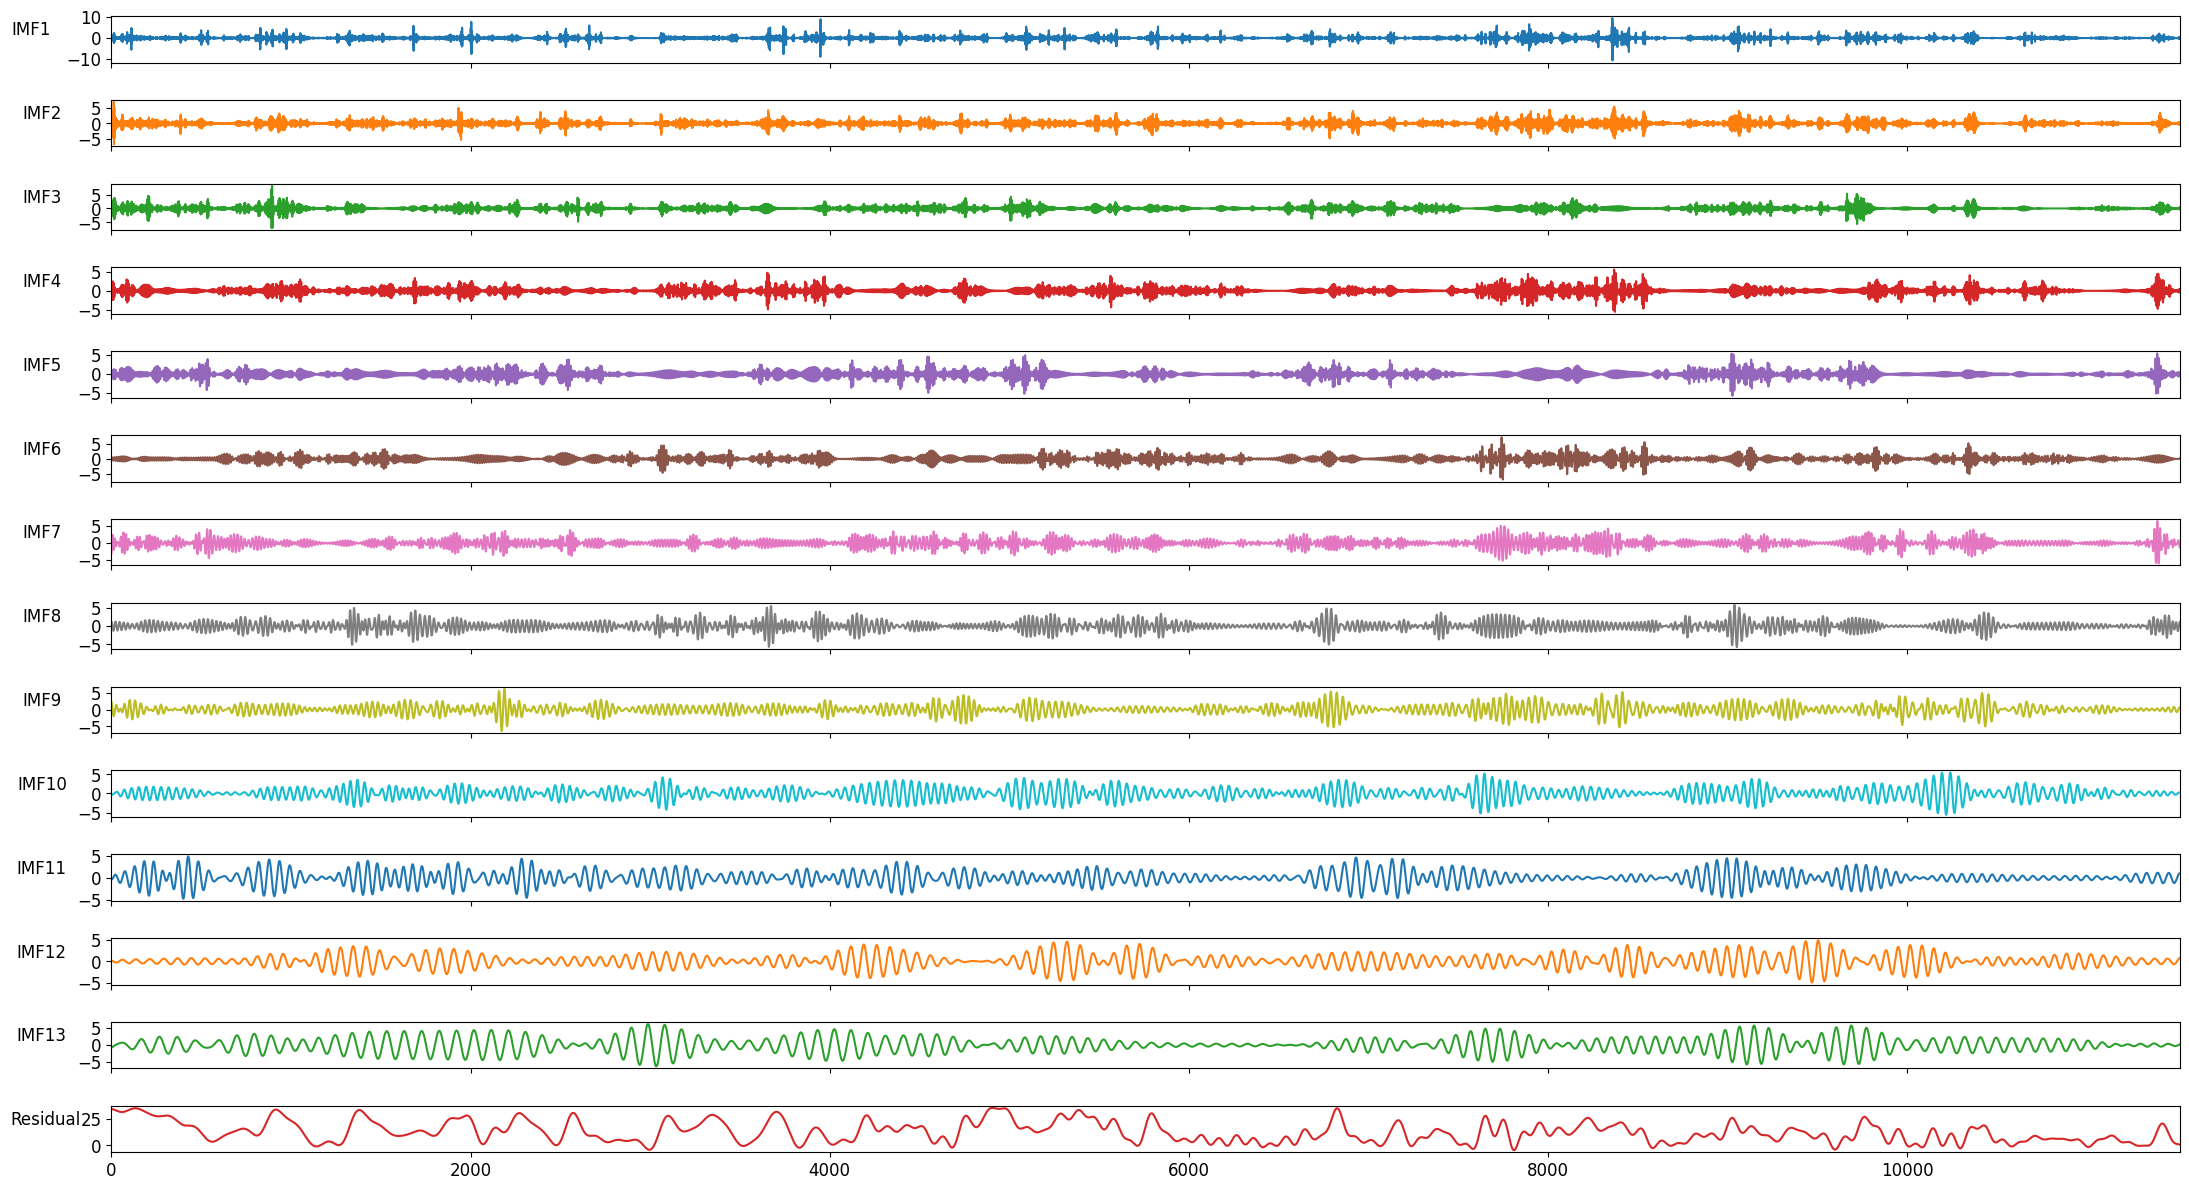

Figure E.2 (a) saved.

=== R2CMSE results: (Figure E.2(b) & (c)) ===
(r=0.15, m=2, n_components=14)
------------------------------------------------------------


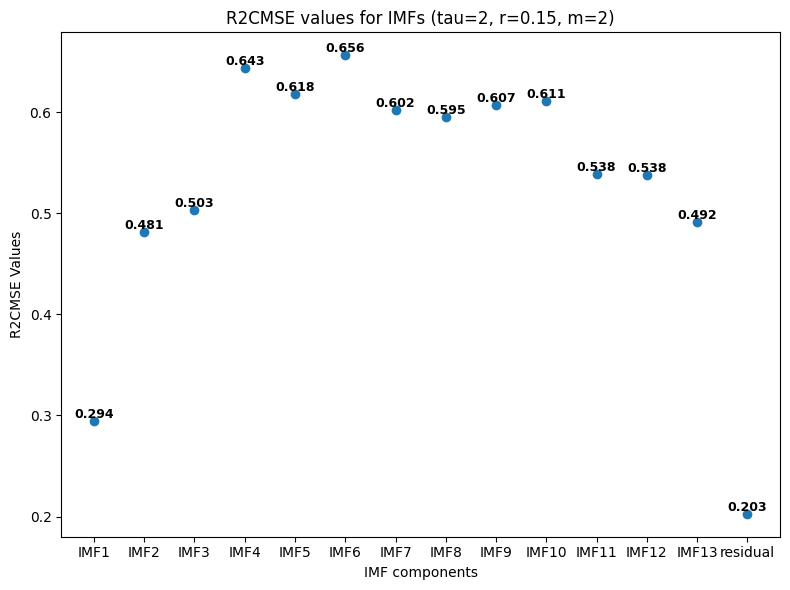

FigureE.2(b) saved: R2CMSE_fujian.png


In [10]:
from pytvfemd import tvfemd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

# ============================TVFEMD Decomposition=================================
col_names = None

print("=== TVFEMD decomposition results (Figure E.2 (a)) ===")
imf_s = tvfemd(a, bsp_order=28, thresh_bwr=0.1)
col_names = [f"IMF{i+1}" for i in range(imf_s.shape[1] - 1)] + ["residual"]
de=pd.DataFrame(imf_s, columns=col_names)
de.to_csv("tvfemd_fujian.csv", index=False)
print("Default result saved: tvfemd_fujian.csv")

# Figure E.2(a):load TVFEMD results
axes = de.plot(subplots=True, legend=False, figsize=(22, 12), fontsize=12)
for i in range(len(col_names) - 1):
    axes[i].set_ylabel(f'IMF{i+1}', labelpad=25.5, rotation='horizontal', fontsize=12)
axes[-1].set_ylabel('Residual', labelpad=25.5, rotation='horizontal', fontsize=12)
plt.xlim(0, 11519)
plt.tight_layout()
plt.subplots_adjust(hspace=0.8)
plt.savefig('tvfemd_fujian.png', dpi=400)
plt.show()
print("Figure E.2 (a) saved.")

# Figure E.2(b):load TVFEMD results
series = imf_s  # shape: (n_samples, n_IMFs)

# ======================= R2CMSE core functions=======================================
def coarse_graining(series, tau):
    L = len(series)
    N = L // tau
    data = np.zeros((tau, N))
    for k in range(tau):
        for i in range(N):
            start = i * tau + k
            end = (i + 1) * tau + k - 1
            segment = series[start:] if end >= L else series[start:end+1]
            data[k, i] = np.mean(segment)
    return data

def sample_entropy_optimized(series, r, m):
    N = len(series)
    if N < m + 1:
        return np.nan, np.nan
    def create_patterns(x, dim):
        return np.lib.stride_tricks.sliding_window_view(x, window_shape=dim)
    def count_matches(patterns, r_val):
        n = len(patterns)
        if n < 2:
            return 0
        dists = squareform(pdist(patterns, metric='chebyshev'))
        np.fill_diagonal(dists, np.inf)
        return np.sum(dists <= r_val)
    patterns_m  = create_patterns(series, m)
    patterns_m1 = create_patterns(series, m + 1)
    B = count_matches(patterns_m,  r)
    A = count_matches(patterns_m1, r)
    N_m, N_m1 = len(patterns_m), len(patterns_m1)
    if B == 0 or A == 0:
        return np.nan, np.nan
    return B / (N_m * (N_m - 1)), A / (N_m1 * (N_m1 - 1))

def r2cmse_value_optimized(series, r, m, tau):
    r_rel = r * np.std(series)
    data = coarse_graining(series, tau)
    tmp1, tmp2 = [], []
    for i in range(tau):
        c2, c3 = sample_entropy_optimized(data[i, :], r_rel, m)
        tmp1.append(c2)
        tmp2.append(c3)
    mean1, mean2 = np.nanmean(tmp1), np.nanmean(tmp2)
    if mean1 == 0 or mean2 == 0:
        return np.nan
    return -np.log(mean2 / mean1)

# ======================= R2CMSE results: Figure E.2(b) & (c)=======================
tau_values  = 2
r_default   = 0.15
m_default   = 2
sensitivity_tau_results = {}
default_r2cmse_results  = None

print("\n=== R2CMSE results: (Figure E.2(b) & (c)) ===")
print(f"(r={r_default}, m={m_default}, n_components={series.shape[1]})")
print("-" * 60)

def run_r2cmse(tau, r, m):
    results = []
    for i in range(series.shape[1]):
        val = r2cmse_value_optimized(series[:, i], r=r, m=m, tau=tau)
        results.append(val)
    return results
default_r2cmse_results = run_r2cmse(tau=tau_values, r=r_default, m=m_default)
# ======================= Figure E.2(b) plot=======================
xf = list(de.columns)
yf = default_r2cmse_results

plt.figure(figsize=(8, 6))
plt.scatter(xf, yf)
for i, txt in enumerate(yf):
    if txt is not None and not np.isnan(txt):
        plt.text(xf[i], txt, f'{txt:.3f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.title('R2CMSE values for IMFs (tau=2, r=0.15, m=2)')
plt.xlabel('IMF components')
plt.ylabel('R2CMSE Values')
plt.tight_layout()
plt.savefig('R2CMSE_TenneT.png', dpi=400)
plt.show()
print("FigureE.2(b) saved: R2CMSE_fujian.png")

Based on these R2CMSE values, the following reconstructed IMF files and Figure E.2 (c) were obtained:

section5.1/trmg(trqg)/tvfemdresults_fujian.csv

### VMD+R2CMSE

In [ ]:
pip install vmdpy pyswarm antropy

In [2]:
df = pd.read_csv('fujian/res_new.csv')
a = np.array(df["Power"].values)

In [3]:
from vmdpy import VMD
from pyswarm import pso
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import antropy as ant
from scipy.spatial.distance import pdist, squareform

def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)

set_seed(42)
#======================= VMD decomposition=======================
class VMD_PSO_Optimizer:
    def __init__(self, signal, tau=0, DC=0, init=1, tol=1e-7, seed=42):
        self.signal = signal
        self.tau = tau
        self.DC = DC
        self.init = init
        self.tol = tol
        self.eval_count = 0
        self.seed = seed
        set_seed(self.seed)

    def fitness_function(self, params):
        K = max(2, min(int(np.round(params[0])), 15))
        alpha = np.round(params[1] / 500) * 500
        try:
            u, u_hat, omega = VMD(self.signal, alpha=alpha, tau=self.tau,
                                  K=K, DC=self.DC, init=self.init, tol=self.tol)
            reconstructed = np.sum(u, axis=0)
            min_len = min(len(self.signal), len(reconstructed))
            fitness = mean_squared_error(self.signal[:min_len], reconstructed[:min_len])
            self.eval_count += 1
            if self.eval_count % 10 == 0:
                print(f"Trial {self.eval_count}: K={K}, alpha={alpha:.0f}, fitness={fitness:.6f}")
            return fitness
        except Exception as e:
            print(f"Decomposition failed: K={K}, alpha={alpha}, Error: {e}")
            return 1e10

    def optimize(self, K_range=(2, 12), alpha_range=(500, 5000), swarmsize=20, maxiter=50):
        set_seed(self.seed)
        print("="*60)
        print(f"Starting PSO | K range: {K_range} | Alpha range: {alpha_range} | seed: {self.seed}")
        print("="*60)
        best_params, best_fitness = pso(
            self.fitness_function, [K_range[0], alpha_range[0]], [K_range[1], alpha_range[1]],
            swarmsize=swarmsize, maxiter=maxiter,
            omega=0.5, phip=1.5, phig=1.5, debug=True
        )
        best_K = int(np.round(best_params[0]))
        best_alpha = np.round(best_params[1] / 500) * 500
        print(f"Best K: {best_K} | Best Alpha: {best_alpha:.0f} | Best fitness: {best_fitness:.6f}")
        return [best_K, best_alpha], best_fitness

    def decompose(self, best_params):
        K, alpha = int(best_params[0]), best_params[1]
        print(f"\nVMD decomposition: K={K}, alpha={alpha:.0f}")
        u, u_hat, omega = VMD(self.signal, alpha=alpha, tau=self.tau,
                              K=K, DC=self.DC, init=self.init, tol=self.tol)
        return u, u_hat, omega


optimizer = VMD_PSO_Optimizer(a)
best_params, best_fitness = optimizer.optimize(
    K_range=(2, 12), alpha_range=(2000, 3000), swarmsize=10, maxiter=20
)
u, u_hat, omega = optimizer.decompose(best_params)

vimf = u.T
pd.DataFrame(vimf).to_csv('vmd_fujian.csv', index=False)# move to data/fujian

series=vimf

# =======================  R2CMSE core functions =======================
def coarse_graining(series, tau):
    L = len(series)
    N = L // tau
    data = np.zeros((tau, N))
    for k in range(tau):
        for i in range(N):
            start = i * tau + k
            end = (i + 1) * tau + k - 1
            segment = series[start:] if end >= L else series[start:end+1]
            data[k, i] = np.mean(segment)
    return data

def sample_entropy_optimized(series, r, m):
    N = len(series)
    if N < m + 1:
        return np.nan, np.nan
    def create_patterns(x, dim):
        return np.lib.stride_tricks.sliding_window_view(x, window_shape=dim)
    def count_matches(patterns, r_val):
        n = len(patterns)
        if n < 2:
            return 0
        dists = squareform(pdist(patterns, metric='chebyshev'))
        np.fill_diagonal(dists, np.inf)
        return np.sum(dists <= r_val)
    patterns_m  = create_patterns(series, m)
    patterns_m1 = create_patterns(series, m + 1)
    B = count_matches(patterns_m,  r)
    A = count_matches(patterns_m1, r)
    N_m, N_m1 = len(patterns_m), len(patterns_m1)
    if B == 0 or A == 0:
        return np.nan, np.nan
    return B / (N_m * (N_m - 1)), A / (N_m1 * (N_m1 - 1))

def r2cmse_value_optimized(series, r, m, tau):
    r_rel = r * np.std(series)
    data = coarse_graining(series, tau)
    tmp1, tmp2 = [], []
    for i in range(tau):
        c2, c3 = sample_entropy_optimized(data[i, :], r_rel, m)
        tmp1.append(c2)
        tmp2.append(c3)
    mean1, mean2 = np.nanmean(tmp1), np.nanmean(tmp2)
    if mean1 == 0 or mean2 == 0:
        return np.nan
    return -np.log(mean2 / mean1)

# ======================= R2CMSE results=======================
tau_values  = 2
r_default   = 0.15
m_default   = 2
sensitivity_tau_results = {}
default_r2cmse_results  = None

print(f"(r={r_default}, m={m_default}, n_components={series.shape[1]})")
print("-" * 60)

def run_r2cmse(tau, r, m):
    results = []
    for i in range(series.shape[1]):
        val = r2cmse_value_optimized(series[:, i], r=r, m=m, tau=tau)
        results.append(val)
    return results

results_tau = run_r2cmse(tau=tau_values, r=r_default, m=m_default)

print(results_tau)

Starting PSO | K range: (2, 12) | Alpha range: (2000, 3000) | seed: 42
No constraints given.
Trial 10: K=3, alpha=2500, fitness=3.700824
Trial 20: K=7, alpha=2500, fitness=1.437839
Best after iteration 1: [  11.36860014 2124.70951608] 0.4514320155586852
Trial 30: K=12, alpha=2000, fitness=0.347636
New best for swarm at iteration 2: [  12.         2111.18667824] 0.34763579903691366
Best after iteration 2: [  12.         2111.18667824] 0.34763579903691366
Trial 40: K=12, alpha=2000, fitness=0.347636
Best after iteration 3: [  12.         2111.18667824] 0.34763579903691366
Trial 50: K=12, alpha=2000, fitness=0.347636
Best after iteration 4: [  12.         2111.18667824] 0.34763579903691366
Trial 60: K=12, alpha=2000, fitness=0.347636
Best after iteration 5: [  12.         2111.18667824] 0.34763579903691366
Trial 70: K=12, alpha=2000, fitness=0.347636
Best after iteration 6: [  12.         2111.18667824] 0.34763579903691366
Trial 80: K=12, alpha=2000, fitness=0.347636
Best after iteration 

NameError: name 'squareform' is not defined

Based on results_tau, the following reconstructed IMF file was obtained:

section5.1/vrlg/vmd_decomposition_fujian.csv

### WT + R2CMSE

In [2]:
df = pd.read_csv('fujian/res_new.csv')
a = np.array(df["Power"].values)

In [7]:
#======================= WT decomposition=======================
import pywt
from scipy.spatial.distance import pdist, squareform

signal_1d = a
def wavelet_decomp_wrapper(signal):
    return pywt.wavedec(signal, wavelet='db4', level=None)

coeffs = wavelet_decomp_wrapper(a)

coeffs = pywt.wavedec(signal_1d, wavelet='db4', level=None)
N = len(signal_1d)

def reconstruct_imfs(coeffs, wavelet='db4', original_length=None):
    if original_length is None:
        original_length = len(coeffs[-1]) * 2
    imfs = []
    for i in range(1, len(coeffs)):
        coeffs_i = [np.zeros_like(c) for c in coeffs]
        coeffs_i[i] = coeffs[i]
        imfs.append(pywt.waverec(coeffs_i, wavelet)[:original_length])
    coeffs_approx = [coeffs[0]] + [np.zeros_like(c) for c in coeffs[1:]]
    trend = pywt.waverec(coeffs_approx, wavelet)[:original_length]
    return imfs, trend

imfs_wt, trend_wt = reconstruct_imfs(coeffs, wavelet='db4', original_length=N)

data_dict = {'Trend': trend_wt}
data_dict.update({f'IMF{i+1}': imf for i, imf in enumerate(imfs_wt)})
pd.DataFrame(data_dict).to_csv('wt_fujian.csv', index=False)# move to data/fujian


# =======================  R2CMSE core functions =======================
imf_keys = [k for k in data_dict.keys() if k.startswith('IMF')]
all_keys =   imf_keys + ['Trend']
series = np.column_stack([data_dict[k] for k in all_keys])

# =======================  R2CMSE core functions=======================

def coarse_graining(series, tau):
    L = len(series)
    N = L // tau
    data = np.zeros((tau, N))
    for k in range(tau):
        for i in range(N):
            start = i * tau + k
            end = (i + 1) * tau + k - 1
            segment = series[start:] if end >= L else series[start:end+1]
            data[k, i] = np.mean(segment)
    return data

def sample_entropy_optimized(series, r, m):
    N = len(series)
    if N < m + 1:
        return np.nan, np.nan
    def create_patterns(x, dim):
        return np.lib.stride_tricks.sliding_window_view(x, window_shape=dim)
    def count_matches(patterns, r_val):
        n = len(patterns)
        if n < 2:
            return 0
        dists = squareform(pdist(patterns, metric='chebyshev'))
        np.fill_diagonal(dists, np.inf)
        return np.sum(dists <= r_val)
    patterns_m  = create_patterns(series, m)
    patterns_m1 = create_patterns(series, m + 1)
    B = count_matches(patterns_m,  r)
    A = count_matches(patterns_m1, r)
    N_m, N_m1 = len(patterns_m), len(patterns_m1)
    if B == 0 or A == 0:
        return np.nan, np.nan
    return B / (N_m * (N_m - 1)), A / (N_m1 * (N_m1 - 1))

def r2cmse_value_optimized(series, r, m, tau):
    r_rel = r * np.std(series)
    data = coarse_graining(series, tau)
    tmp1, tmp2 = [], []
    for i in range(tau):
        c2, c3 = sample_entropy_optimized(data[i, :], r_rel, m)
        tmp1.append(c2)
        tmp2.append(c3)
    mean1, mean2 = np.nanmean(tmp1), np.nanmean(tmp2)
    if mean1 == 0 or mean2 == 0:
        return np.nan
    return -np.log(mean2 / mean1)

# ======================= R2CMSE results=======================
tau_values  = 2
r_default   = 0.15
m_default   = 2

print(f"(r={r_default}, m={m_default}, n_components={series.shape[1]})")

def run_r2cmse(tau, r, m):
    results = []
    for i in range(series.shape[1]):
        val = r2cmse_value_optimized(series[:, i], r=r, m=m, tau=tau)
        results.append(val)
    return results

results_tau = run_r2cmse(tau=tau_values, r=r_default, m=m_default)

print(results_tau)

Timer unit: 1e-09 s

Total time: 0.00384272 s
File: /usr/local/lib/python3.12/dist-packages/pywt/_multilevel.py
Function: wavedec at line 49

Line #      Hits         Time  Per Hit   % Time  Line Contents
    49                                           def wavedec(data, wavelet, mode='symmetric', level=None, axis=-1):
    50                                               """
    51                                               Multilevel 1D Discrete Wavelet Transform of data.
    52                                           
    53                                               Parameters
    54                                               ----------
    55                                               data: array_like
    56                                                   Input data
    57                                               wavelet : Wavelet object or name string
    58                                                   Wavelet to use
    59                                

Based on results_tau, the following reconstructed IMF file was obtained:

section5.1/wrgg/wt_decomposition_fujian.csv

### EMD + R2CMSE

In [2]:
pip install EMD-signal

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 2.8 MB/s eta 0:00:00


In [4]:
df = pd.read_csv('fujian/res_new.csv')
a = np.array(df["Power"].values)

In [8]:
from PyEMD import EMD
from scipy.spatial.distance import pdist, squareform

#======================= EMD decomposition reaults=======================
emd = EMD()

IMFs = emd(a)
IMFs = IMFs.T

emd_cols_fj = [f"IMF{i+1}" for i in range(IMFs.shape[1]-1)] + ["residual"]
pd.DataFrame(IMFs, columns=emd_cols_fj).to_csv('emdf.csv', index=False)#move to data/fujian

series = IMFs

# =======================  R2CMSE core functions =======================
def coarse_graining(series, tau):
    L = len(series)
    N = L // tau
    data = np.zeros((tau, N))
    for k in range(tau):
        for i in range(N):
            start = i * tau + k
            end = (i + 1) * tau + k - 1
            segment = series[start:] if end >= L else series[start:end+1]
            data[k, i] = np.mean(segment)
    return data

def sample_entropy_optimized(series, r, m):
    N = len(series)
    if N < m + 1:
        return np.nan, np.nan
    def create_patterns(x, dim):
        return np.lib.stride_tricks.sliding_window_view(x, window_shape=dim)
    def count_matches(patterns, r_val):
        n = len(patterns)
        if n < 2:
            return 0
        dists = squareform(pdist(patterns, metric='chebyshev'))
        np.fill_diagonal(dists, np.inf)
        return np.sum(dists <= r_val)
    patterns_m  = create_patterns(series, m)
    patterns_m1 = create_patterns(series, m + 1)
    B = count_matches(patterns_m,  r)
    A = count_matches(patterns_m1, r)
    N_m, N_m1 = len(patterns_m), len(patterns_m1)
    if B == 0 or A == 0:
        return np.nan, np.nan
    return B / (N_m * (N_m - 1)), A / (N_m1 * (N_m1 - 1))

def r2cmse_value_optimized(series, r, m, tau):
    r_rel = r * np.std(series)
    data = coarse_graining(series, tau)
    tmp1, tmp2 = [], []
    for i in range(tau):
        c2, c3 = sample_entropy_optimized(data[i, :], r_rel, m)
        tmp1.append(c2)
        tmp2.append(c3)
    mean1, mean2 = np.nanmean(tmp1), np.nanmean(tmp2)
    if mean1 == 0 or mean2 == 0:
        return np.nan
    return -np.log(mean2 / mean1)

# ======================= R2CMSE results=======================
tau_values  = 2
r_default   = 0.15
m_default   = 2

print(f"(r={r_default}, m={m_default}, n_components={series.shape[1]})")

def run_r2cmse(tau, r, m):
    results = []
    for i in range(series.shape[1]):
        val = r2cmse_value_optimized(series[:, i], r=r, m=m, tau=tau)
        results.append(val)
    return results

results_tau = run_r2cmse(tau=tau_values, r=r_default, m=m_default)
print(results_tau)

Timer unit: 1e-09 s

Total time: 20.6976 s
File: /usr/local/lib/python3.12/dist-packages/PyEMD/EMD.py
Function: EMD.__call__ at line 119

Line #      Hits         Time  Per Hit   % Time  Line Contents
   119                                               def __call__(self, S: np.ndarray, T: Optional[np.ndarray] = None, max_imf: int = -1) -> np.ndarray:
   120         1     2.07e+10 2.07e+10    100.0          return self.emd(S, T=T, max_imf=max_imf)

(r=0.15, m=2, n_components=14)
[np.float64(0.500566795004456), np.float64(0.5071793817988044), np.float64(0.44352985080872576), np.float64(0.4405311742395561), np.float64(0.5671546904148357), np.float64(0.5122510790800258), np.float64(0.4174833581801541), np.float64(0.20893721471738852), np.float64(0.09126017833212424), np.float64(0.03753210723261377), np.float64(0.015031603773694254), np.float64(0.005542556905079114), np.float64(0.0012750159029232039), np.float64(3.184142463270208e-05)]
Timer unit: 1e-09 s

Total time: 9.23751 s
File: /tmp/

Based on results_tau, the following reconstructed IMF files was obtained:

section5.1/ermg/emdfujian.csv

# **Fujian dataset results, using hybrid models in section 5.1**

**tvfemdresults_fujian.csv in trmg/trqg file**
| IMF | R2CMSE values | Reconstruction for TRMG |
|:---:|:---:|:---:|
| IMF1 | 0.2941932426488651 | sub1 |
| IMF2 | 0.4811190704671143 | sub2 |
| IMF3 | 0.5031439168072264 | sub2 |
| IMF4 | 0.643320272369159 | sub3 |
| IMF5 | 0.6178082635524513 | sub4 |
| IMF6 | 0.6562927866576244 | sub3 |
| IMF7 | 0.6021571777440984 | sub4 |
| IMF8 | 0.5953036281705653 | sub4 |
| IMF9 | 0.6066973953611912 | sub4 |
| IMF10 | 0.6108192435848091 | sub4 |
| IMF11 | 0.5384361171474391 | sub2 |
| IMF12 | 0.537893214931095 | sub2 |
| IMF13 | 0.49175621892778704 | sub2 |
| Res | 0.20275346476618353 | sub5 |

**emdfujian.csv in ermg file**
| IMF | R2CMSE values | Reconstruction for ERMG |
|:---:|:---:|:---:|
| IMF1 | 0.5186190901546025 | esub1 |
| IMF2 | 0.6095091605091645 | esub2 |
| IMF3 | 0.8656929737133856 | esub3 |
| IMF4 | 0.6880817677288262 | esub2 |
| IMF5 | 0.6149674612961255 | esub2 |
| IMF6 | 0.5349274241659843 | esub1 |
| IMF7 | 0.2554552283416495 | esub4 |
| IMF8 | 0.12776242904316584 | esub4 |
| IMF9 | 0.049760929346801326 | esub5 |
| IMF10 | 0.023205164140334078 | esub5 |
| IMF11 | 0.00920415476249319 | esub5 |
| Res | 0.0005976822947434586 | esub5 |

**wt_decomposition_fujian.csv in wrgg file**
| IMF | R2CMSE values | Reconstruction for WRGG |
|:---:|:---:|:---:|
| IMF1 | 0.03103446908596423 | Wsub1 |
| IMF2 | 0.07864759007701673 | Wsub1 |
| IMF3 | 0.15546682644666518 | Wsub1 |
| IMF4 | 0.27782265176568754 | Wsub3 |
| IMF5 | 0.443107529612913 | Wsub2 |
| IMF6 | 0.5913125497181745 | Wsub2 |
| IMF7 | 0.7005004036713423 | Wsub4 |
| IMF8 | 0.7751592209542858 | Wsub4 |
| IMF9 | 0.5725916445443033 | Wsub2 |
| IMF10 | 0.2826456407087229 | Wsub3 |
| Res | 0.006837348646685774 | Wsub5 |

**vmd_decomposition_fujian.csv in vrlg file**
| IMF | R2CMSE values | Reconstruction for VRLG |
|:---:|:---:|:---:|
| IMF1 | 0.12909246590841994 | Vsub4 |
| IMF2 | 0.20112040818548052 | Vsub1 |
| IMF3 | 0.40216817578824515 | Vsub3 |
| IMF4 | 0.4366079473846903 | Vsub3 |
| IMF5 | 0.512583783326154 | Vsub2 |
| IMF6 | 0.5837203283314564 | Vsub2 |
| IMF7 | 0.6012989984608547 | Vsub2 |
| IMF8 | 0.5797593123568193 | Vsub2 |
| IMF9 | 0.6020658104256013 | Vsub2 |
| IMF10 | 0.5178836564159346 | Vsub2 |
| IMF11 | 0.24269636364182717 | Vsub1 |
| Res | 0.05131993120881324 | Vsub5 |

**tsmg_fujian.csv in tsmg file**
| IMF | SE values | Reconstruction for TSMG |
|:---:|:---:|:---:|
| IMF1 | 0.4130507904159813 | sesub1 |
| IMF2 | 0.4999522484530065 | sesub2 |
| IMF3 | 0.36064297666438727 | sesub1 |
| IMF4 | 0.48017846974306183 | sesub2 |
| IMF5 | 0.5245282030621283 | sesub2 |
| IMF6 | 0.5771241669200535 | sesub3 |
| IMF7 | 0.6067881411139512 | sesub3 |
| IMF8 | 0.6234338893590501 | sesub3 |
| IMF9 | 0.615614437674018 | sesub3 |
| IMF10 | 0.6024791520350234 | sesub3 |
| IMF11 | 0.4977097134798775 | sesub2 |
| IMF12 | 0.4786475791749607 | sesub2 |
| IMF13 | 0.4968756518556765 | sesub2 |
| Res | 0.5500556308645305 | sesub3 |